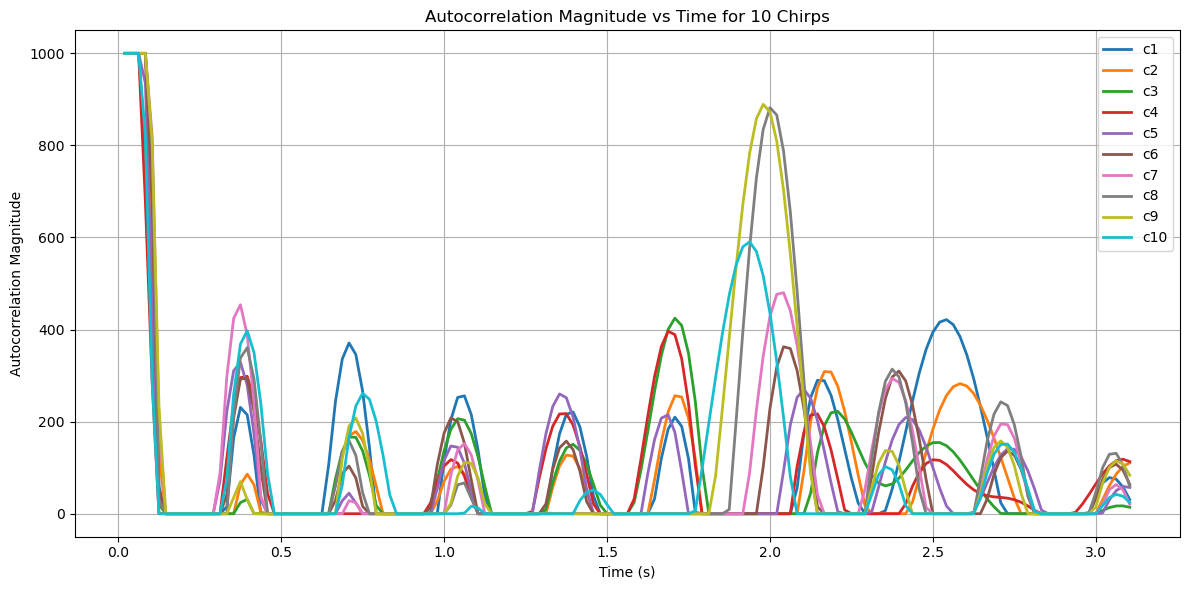

/tmp/ipykernel_382545/3291136862.py:55: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


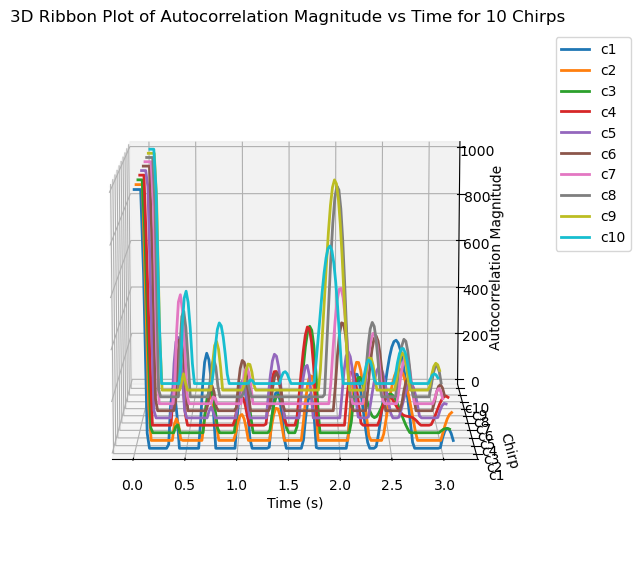

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Load the Excel file
excel_path = "N6RFM Fig 9 chart for Alex Frontiers.xlsx"
df = pd.read_excel(excel_path, sheet_name="Sheet1")

# Extract time values from row 1 starting at column 7 (index 6)
time_values = df.iloc[1, 6:].astype(float).values

# Extract chirp labels and values
chirp_labels = df.iloc[2:12, 2].tolist()
chirp_values = [df.iloc[i, 6:].astype(float).values for i in range(2, 12)]

# Create DataFrame for 2D plot
correlations = pd.DataFrame(data=np.array(chirp_values).T, columns=chirp_labels)
correlations['Time (s)'] = time_values
correlations.set_index('Time (s)', inplace=True)

# 2D Plot using pandas
correlations.plot(figsize=(12, 6), linewidth=2)
plt.title("Autocorrelation Magnitude vs Time for 10 Chirps")
plt.xlabel("Time (s)")
plt.ylabel("Autocorrelation Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3D Ribbon-style plot using matplotlib
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

# Prepare data for 3D plot
X = np.array([correlations.index.values] * 10)
Y = np.array([[i + 1] * len(correlations) for i in range(10)])
Z = correlations.values.T

# Plot each chirp trace as a ribbon
for i, label in enumerate(chirp_labels):
    ax.plot(X[i], Y[i], Z[i], label=label, linewidth=2)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Chirp")
ax.set_zlabel("Autocorrelation Magnitude")
ax.set_yticks(range(1, 11))
ax.set_yticklabels(chirp_labels)
ax.set_title("3D Ribbon Plot of Autocorrelation Magnitude vs Time for 10 Chirps")

# Set Excel-like view
ax.view_init(elev=10, azim=270)

ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()
